# SKKU 2024 Challenge
## Dicke State Preparation

In [1]:
import numpy as np
import qiskit
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram

In [2]:
## utils.py
backend = Aer.get_backend("aer_simulator")
backend2 = Aer.get_backend("statevector_simulator")

def MeasurementResultHandler(result:dict, num_qubits:int):
	new_result = {}
	for i in range(2**num_qubits):
		temp = format(i,"#b")[2:]
		key = "".join(["0" for _ in range(num_qubits - len(temp))]) + temp
		new_result[key] = np.array(result[format(i,"#x")]) if result.get(format(i,"#x")) else np.array(0)
	return new_result

### Part 1

#### a)

The Hamiltonian whose eigenvalues differs by Hamming weight in $n$-qubit system can be constructed by the projector onto the space of fixed Hamming weight $i$. That is,
$$
\mathcal{H} = \sum_{i=0}^{2^n -1} e_i P_{i}
$$
The eigenvalue $e_i$ can be freely chosen, without repeatation. For example, we can choose $e_i = i$ where the eigenvalue is just the Hamming weight $i$.
Note that the given hamiltonian can have ${}_{n}C_{i}$ for $e_i$.

#### b) 
Let $k$ denote the minimum number of bits required to measure hamming weight of the state. Then
$$
k = \left[\log_{2}(n+1)\right]
$$
where $\left[ a \right]$ denotes the smallest integer larger than $a$.

### Part 2

In [3]:
def HammingWeight(vector, num_shot=100):
	n = np.log2(vector.shape[0]).astype(np.int64) # num of physical qubits
	k = np.ceil(np.log2(n+1)).astype(np.int64)
	N = 2**k - 1

	qc = qiskit.QuantumCircuit(n + k, k) 
	# Phase 1
	# Register Qubits
	state_computation = qiskit.QuantumCircuit(k)
	for i in range(k):
		state_computation.h(i)
	# State Preparation
	state_preparation = qiskit.QuantumCircuit(n)
	state_preparation.initialize(vector, state_preparation.qubits)

	qc = qc.compose(state_computation, qubits=[i for i in range(0,k,1)])
	qc = qc.compose(state_preparation, qubits=[i for i in range(k,k+n,1)])

	# Phase 2
	for i in range(0,k):
		theta = n*np.pi/(N+1)*2**i
		qc.rz(theta, i)

	# Phase 3
	for i in range(k-1,-1,-1):
		theta = 2*np.pi/(N+1) * 2**i
		for j in range(k+n-1,k-1,-1):
			qc.crz(theta, i, j)
   
	# Phase 4
	# IQFT
	for i in range(k-1,-1,-1): # 0 -> k-1
		for j in range(k-1, i, -1):
			theta = -2*np.pi / 2**(j-i+1)
			qc.crz(theta, j, i)
		qc.h(i)			

	for i in range(k):
		qc.measure(i,k-i-1)
  
	result = MeasurementResultHandler(backend.run(qc, shots=num_shot).result().data()["counts"], k)
	
	return qc, result

### Part 3

#### a) $\ket{\psi} = \ket{11}$

The Hamming weight of the given state is 2. The circuit execution confirms that the Hamming weight is also 2.

#### b) $\ket{\psi} = \ket{01}$


The Hamming weight of the given state is 1. The circuit execution confirms that the Hamming weight is also 1.

#### c) $\ket{\psi} = \frac{1}{\sqrt{2}} \left(\ket{00} + \ket{11} \right)$


The given state has a 50\% probability of being observed with a Hamming weight of 0, and a 50\% probability of having a Hamming weight of 2.

#### d) $\ket{\psi} = \frac{1}{\sqrt{3}} \left( \ket{011} + \ket{101} + \ket{110} \right)$

The Hamming weight of the given state is 2. The circuit execution confirms that the Hamming weight is also 2.

#### e) Explain the result in part c) above.

The given state has a 50\% probability of being observed with a Hamming weight of 0, and a 50\% probability of having a Hamming weight of 2.


#### a) 
$$
\ket{\psi} = \ket{11}
$$

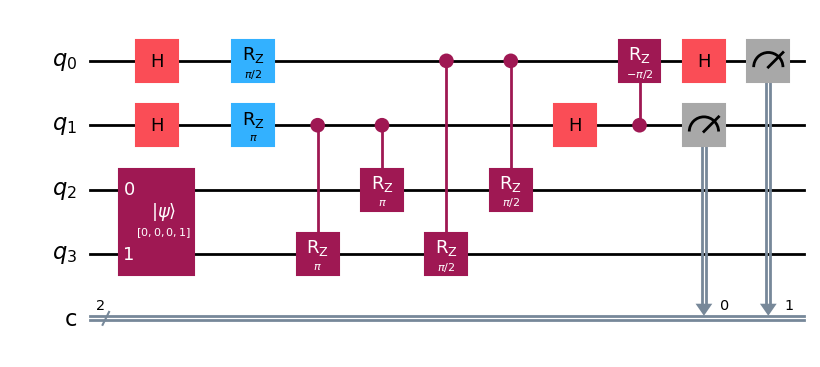

In [4]:
psi = np.array([0,0,0,1])
qc, result = HammingWeight(psi)
hist = plot_histogram(result, sort='hamming', target_string='00')
qc.draw(output="mpl", filename="../report/figure/exercise_3_a_circuit.pdf")

In [5]:
hist.savefig("../report/figure/exercise_3_a_hist.pdf")

#### b)
$$
\ket{\psi} = \ket{01}
$$

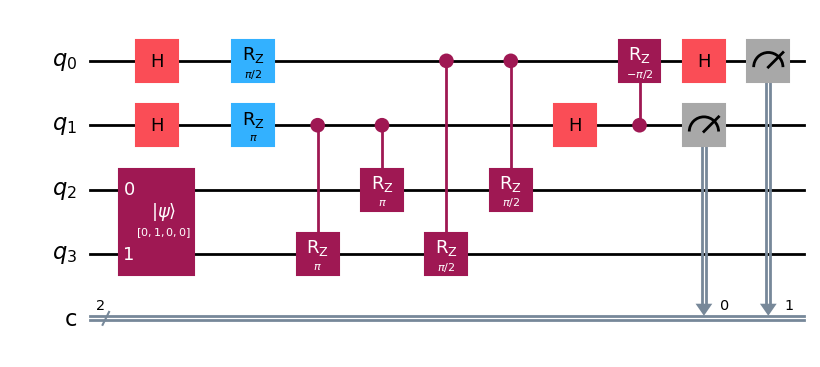

In [6]:
psi = np.array([0,1,0,0])
qc, result = HammingWeight(psi)
hist = plot_histogram(result, sort='hamming', target_string='00')
qc.draw(output="mpl", filename="../report/figure/exercise_3_b_circuit.pdf")

In [7]:
result

{'00': array(0), '01': array(100), '10': array(0), '11': array(0)}

In [8]:
hist.savefig("../report/figure/exercise_3_b_hist.pdf")


#### c) 
$$
\ket{\psi} = \frac{1}{\sqrt{2}} \left(\ket{00} + \ket{11} \right)
$$


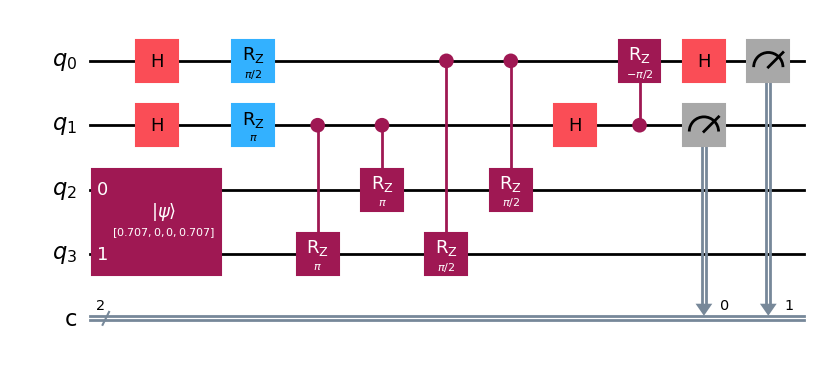

In [9]:
psi = np.array([1,0,0,1])/np.sqrt(2)
qc, result = HammingWeight(psi)
hist = plot_histogram(result, sort='hamming', target_string='00')
qc.draw(output="mpl", filename="../report/figure/exercise_3_c_circuit.pdf")

In [10]:
hist.savefig("../report/figure/exercise_3_c_hist.pdf")


#### d)
$$
\ket{\psi} = \frac{1}{\sqrt{3}} \left( \ket{011} + \ket{101} + \ket{110} \right)
$$


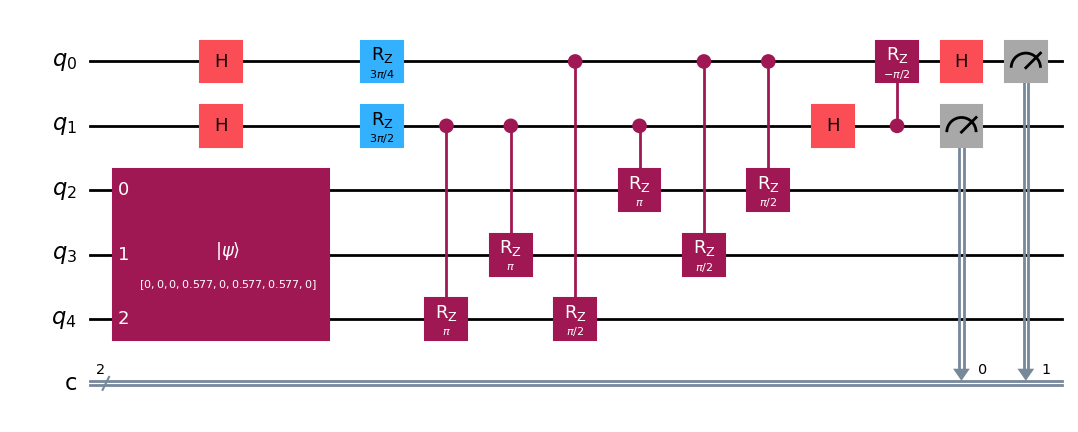

In [11]:
psi = np.array([0,0,0,1,0,1,1,0])/np.sqrt(3)
qc, result = HammingWeight(psi)
hist = plot_histogram(result)
qc.draw(output="mpl", filename="../report/figure/exercise_3_d_circuit.pdf")

In [12]:
hist.savefig("../report/figure/exercise_3_d_hist.pdf")

#### e)
The given state has a 50\% probability of being observed with a Hamming weight of 0, and a 50\% probability of having a Hamming weight of 2.

### Part 4

The post-measurement state can be used to prepare Dicke state. From the Eq. \ref{eq:post_measurement_state}, 
we see that the initially given state projected on to the space of fixed Hamming weight $x$, therefore, becomes a linear combination computational bases of Hamming weight $x$.
For example of three-qubit system, and $x=2$, the basis is $\{\ket{011}, \ket{101}, \ket{110}\}$. 
Here Dicke state in $n$-qubit system and Hamming weight $k$ has form:
$$
\ket{D_{n,k}} = \frac{1}{\sqrt{{}_n C_{k}}} \sum_{i=1}^{{}_n C_{k}} \ket{e_{i}}
$$
where $\ket{e_i}$ is an element of basis of Hamming weight $k$ whose the number of basis is ${}_n C_{k}$.
Considering the whole coefficients are equal, the initial state before the measuring Hamming weight also has the same coefficients in the basis of computational basis.
Such state is just $+$ state:
$$
\ket{\psi} = \ket{++ \cdots +} = \frac{1}{\sqrt{2^n}} \sum_{i=0}^{2^n -1} \ket{i}
$$
where $i$ denotes the bit string. After measuring Hamming weight $k$, the post-measurement state $\ket{\bar{\psi}}$ becomes Dicke state $\ket{D_{n,k}}$.


### Part 5

#### a) What is the probability that the state will be measured? 
Preparing + state, $\ket{\psi} = \ket{+}^{\otimes n}$, the probability that we measure Hamming weight $k$ is $p_{a} = \left| P_{a} \ket{\psi} \right|^{2}$.
Among the computational basis, $\{\ket{0}, \ket{1}, \cdots, \ket{2^n}-1\}$, the number of basis whose Hamming weight is ${}_n C_{k}$. Then,
\begin{equation}
	p_{n,k} = \left| P_{k} \ket{\psi} \right|^{2} = \left| \frac{{}_n C_{k}}{\sqrt{2^n}} \right|^{2} = \frac{({}_n C_k)^{2}}{2^n}.
\end{equation}

Therefore, in $n=100, k=50$, we have $p_{n,k} \simeq 0.07959$. 

#### b) What is the minimum number of measurements required?

At least 13 shots are required for the expectation value of the number of measurements in the Dicke state $ket{D_{n=100,k=50}}$ to exceed 1. 
With this, the probability of measuring the Dicke state $\ket{D_{n=100,k=50}}$ is approximately 66%.

#### c) How many gates are required?

In Phase 1, we prepare the control register $C$, consisting of 7 qubits in initial state $\ket{0}_C$.
We also prepare $\ket{\psi}$  the system qubits. As discussed in Exercise 4, we initialize the system qubits in the $\ket{+}$ state, requiring 100 Hadamard gate in this phase. 
In Phase 2, we apply 7 Hadamard gates to the control register.
In Phase 3, we apply 7 Rz gates to the control register qubits.
In Phase 4, we perform the controlled unitary gate. This requires 100 Controlled RZ gate per register qubit, therefore, we need 700 controlled Rz gates.
In Phase 5, we perform  IQFT on controlled register qubits. 
This phase involves 7 hadamard gate and it applies controlled Rz gate that act on qubit in $j$ as control and qubit $i$ as target, 
where $i<j \leq k$ and $i$ runs from 0 to 7. Thus, we need 7 hadamard gate and 21 controlled Rz gate. 
Therefore, we need 114 Hadamard gates, 721 controlled Z gate, and 7 Rz gates.  